# Compare MNI-aligned FA maps between group

1. JHU atlas (only has main tracts....)
    * 2sTTest on each Tract --> no result outstanding.....
2. TBSS approach (from Simone Schwizers's script)
    * create the meanFA image + skeletonise it ??  |tbss_3_postreg)
    * projects all subjects FA data onto the mean FA skeleton | tbss_4_prestats
    * just ran 2ndLevel SPMs on skeletonised FA maps 
* -->  no result outstanding.....



## 2. TBSS approach 

#### tbss_3_postreg

base_folder=/Volumes/G_ADABD_Largefiles$/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives
for sub in $(seq -w 1 66); do cp ${base_folder}/dwi_preproc/sub-${sub}/sub-${sub}_FA_in_MNI.nii.gz ${base_folder}/dwi_FA2ndLevel/sub-${sub}_FA_in_MNI.nii.gz; done
fslmerge -t allSubs_FA.nii.gz sub-*_FA_in_MNI.nii.gz

"creating valid mask and mean FA"
fslmaths allSubs_FA -max 0 -Tmin -bin mean_FA_mask -odt char
fslmaths allSubs_FA -mas mean_FA_mask all_FA
fslmaths allSubs_FA -Tmean mean_FA

tbss_skeleton -i mean_FA -o mean_FA_skeleton

#### tbss_4_prestats
thresh=0.2
echo $thresh > thresh.txt # save
fslmaths mean_FA_skeleton -thr $thresh -bin mean_FA_skeleton_mask

fslmaths mean_FA_mask -mul -1 -add 1 -add mean_FA_skeleton_mask mean_FA_skeleton_mask_dst # creating skeleton distancemap (for use in projection search)
distancemap -i mean_FA_skeleton_mask_dst -o mean_FA_skeleton_mask_dst
tbss_skeleton -i mean_FA -p $thresh mean_FA_skeleton_mask_dst ${FSLDIR}/data/standard/LowerCingulum_1mm all_FA all_FA_skeletonised
--> now run stats

#### stats
fslsplit all_FA_skeletonised -t 
--> rename here in noteboook


run normal 2ndLevel SPM ?!

In [ ]:
import os
directory =  '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/skeletonised' 
for i in range(66):
    old_name = os.path.join(directory, f'vol{i:04d}.nii.gz')
    new_name = os.path.join(directory, f'sub-{i+1:02d}_FA_skeletonised.nii.gz')    
    os.rename(old_name, new_name)



In [1]:
import os.path as op
import nibabel as nib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting


bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
bids_folder_orig ='/mnt_03/ds-dnumrisk' 
subList = [f'{i:02d}' for i in range(1, 67)]

plot_folder = op.join(bids_folder, 'plots_and_ims', 'DTI')
# add group info
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()


## 2. TBSS 

In [2]:
import pandas as pd
n_samples = len(subList)
design_matrix = pd.DataFrame(np.array([[1] * n_samples, group_list['group'].values]).T , columns=["intercept", 'group'])
design_matrix

,intercept,group
0,1,0
1,1,1
2,1,0
3,1,1
4,1,0
...,...,...
61,1,0
62,1,0
63,1,0
64,1,0


In [ ]:
spec = 'skeletonised'
pati =  '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/skeletonised' 

cmap_filenames = [os.path.join(pati, f'sub-{sub:02d}_FA_skeletonised.nii.gz') for  sub in range(1, 67)]
cmap_filenames

In [7]:
spec = ''
pati =  '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel'

cmap_filenames = [op.join(pati, f'sub-{sub:02d}_FA_in_MNI.nii.gz') for  sub in range(1, 67)]
cmap_filenames

['/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-01_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-02_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-03_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-04_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-05_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-06_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-07_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/sub-08_FA_in_MNI.nii.gz',
 '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/dwi_FA2ndLevel/

In [8]:
from nilearn.glm.second_level import SecondLevelModel

second_level_model = SecondLevelModel(n_jobs=2).fit(
    cmap_filenames, design_matrix=design_matrix
)

In [9]:
z_map = second_level_model.compute_contrast(output_type="z_score", second_level_contrast='group')

In [10]:
z_map.to_filename(op.join(pati, f'2ndLevel_group_z_map_{spec}.nii.gz'))

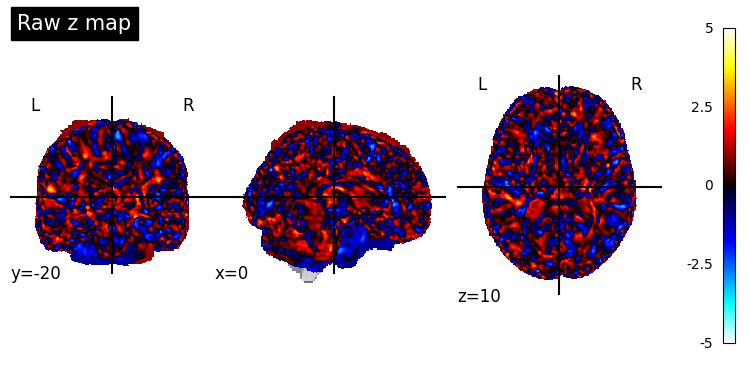

In [11]:
from nilearn import plotting

display = plotting.plot_stat_map(z_map, title="Raw z map")

In [12]:
from nilearn.glm import threshold_stats_img

thresholded_map1, threshold1 = threshold_stats_img(
    z_map,
    alpha=0.1,
    height_control="fpr",
    cluster_threshold=0,
    two_sided=True,
)
thresholded_map1.to_filename(op.join(pati, f'2ndLevel_group_z_map_thresholded_{spec}.nii.gz'))

In [43]:
im_data = thresholded_map1.get_fdata()
im_data[im_data > 0 ] = np.nan
thresholded_map1_neg = nib.Nifti1Image(im_data, thresholded_map1.affine, thresholded_map1.header)
thresholded_map1_neg.to_filename(op.join(pati, '2ndLevel_group_z_map_thresholded_neg.nii.gz'))

im_data = thresholded_map1.get_fdata()
im_data[im_data < 0 ] = np.nan
thresholded_map1_pos = nib.Nifti1Image(im_data, thresholded_map1.affine, thresholded_map1.header)
thresholded_map1_pos.to_filename(op.join(pati, '2ndLevel_group_z_map_thresholded_pos.nii.gz'))

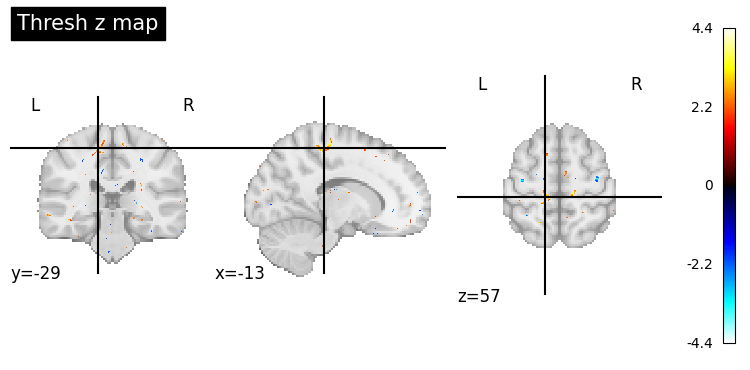

In [34]:
display = plotting.plot_stat_map(thresholded_map1, title="Thresh z map")

## 1. JHU WM-tracts atlas

In [2]:
atlas_data = nib.load('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/JHU-ICBM-labels-1mm_MNI152NLin2009cAsym.nii.gz').get_fdata()
print(atlas_data.shape)

atlas_labels = pd.read_csv('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/JHU-ICBM-labels.csv')
atlas_labels

(193, 229, 193)


,index,name
0,0,Unclassified
1,1,Middle cerebellar peduncle
2,2,Pontine crossing tract (a part of MCP)
3,3,Genu of corpus callosum
4,4,Body of corpus callosum
5,5,Splenium of corpus callosum
6,6,Fornix (column and body of fornix)
7,7,Corticospinal tract R
8,8,Corticospinal tract L
9,9,Medial lemniscus R


In [4]:
# Extract FA per tract
labels = np.unique(atlas_data)
results = {}

for i, label in enumerate(atlas_labels['name']):
    mask = atlas_data == i
    FAs = []
    for sub in subList:
        dwi_dir = op.join(bids_folder, 'derivatives', 'dwi_preproc', f'sub-{sub}')
        fa_in_mni = nib.load(op.join(dwi_dir, f'sub-{sub}_FA_in_MNI.nii.gz')).get_fdata()
        fa_vals = fa_in_mni[mask]
        fa_vals = fa_vals[~np.isnan(fa_vals)]
        FAs.append(np.nanmean(fa_vals)) # mean FA value for the tract ?
    results[label] = FAs


# 14 mins


In [5]:
df_fas= pd.DataFrame(results, index=[int(sub) for sub in subList])
df_fas.index.name = 'subject'
df_fas = df_fas.join(group_list, how='left').set_index('group',append=True)

df_fas.to_csv(op.join(bids_folder, 'derivatives', 'dwi_preproc', 'meanFA_subXtract.csv'))

In [7]:
short_names = [col.split('(')[0].strip() for col in df_fas.columns]

from collections import Counter

counts = Counter()
unique_names = []
for name in short_names:
    counts[name] += 1
    if counts[name] == 1:
        unique_names.append(name)
    else:
        unique_names.append(f"{name}_{counts[name]}")

df_fas.columns = unique_names

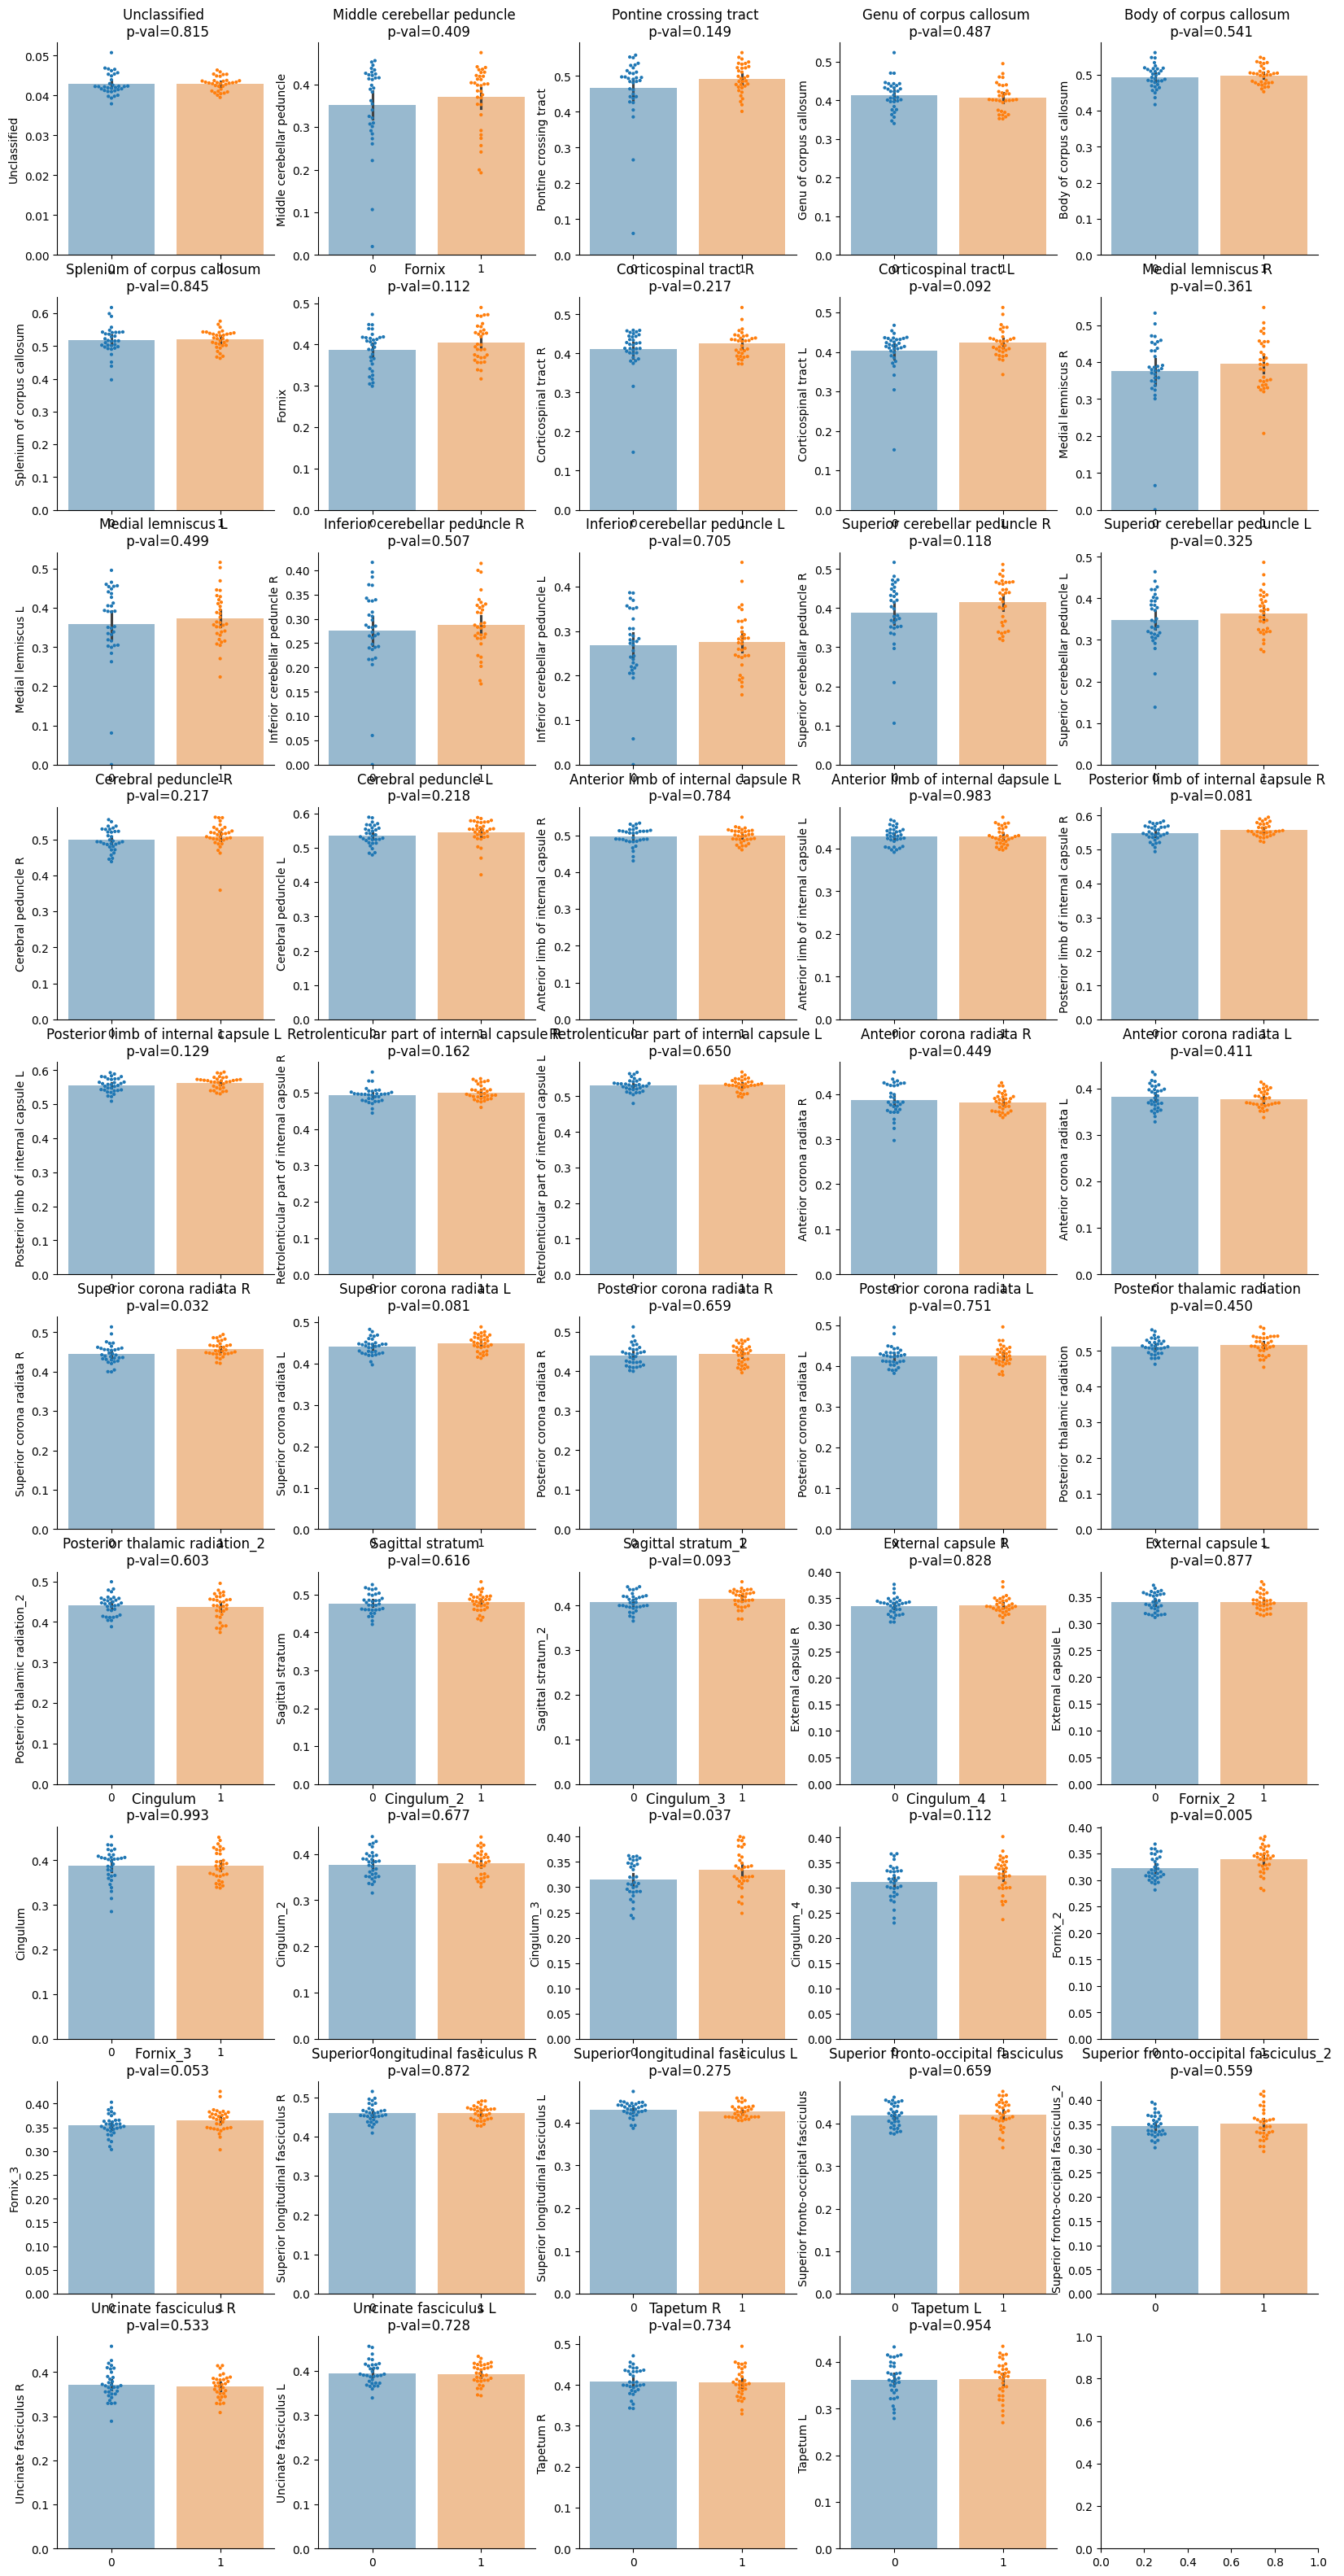

In [8]:
import seaborn as sns
from scipy.stats import ttest_ind

N_tracts = df_fas.shape[1] # 49 
fig, axs = plt.subplots(10,5, figsize=(20,40))

for i, ax in enumerate(axs.flat):
    if i < N_tracts:
        y_var = df_fas.columns[i]
        tmp = df_fas[y_var]
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False,ax=ax)
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=3,legend=False,ax=ax)
        stats = ttest_ind(tmp.xs(0,0,'group'), tmp.xs(1,0,'group'), axis=0, equal_var=False)
        ax.set(title=f'{y_var} \n p-val={stats.pvalue:.3f}', xlabel=None)
        sns.despine()
plt.savefig(op.join(plot_folder, 'meanFA_groupTTests.png'), dpi=300, bbox_inches='tight')   

In [ ]:

# View results
for tract, mean_fa in results.items():
    print(f"{tract}: {mean_fa:.3f}")